# ANA500 Micro-Project 3 - Adult Income Dataset

Jesus Adrian Alvarado Gadea
ANA500, National University

Micro-Project 3 applies machine learning regression techniques, including linear and SVM
regression, and runs the full data science process through Step 5 (Act). This is the first
micro-project that formally tests the hypothesis instead of describing it.

**Problem statement:** Earnings in the 1994 US workforce were spread unevenly across
demographic and employment characteristics. People working similar hours ended up at very
different income levels. I want to describe which recorded attributes are associated with
earning more than $50,000 a year.

**Hypothesis:** Education and hours worked per week are the strongest correlates of earning
above $50,000, with occupation and marital status adding some additional signal.

**Instructor feedback from Micro-Project 2** is incorporated in the Prepare step below:
marital status is recoded to a Married / Not-Married binary, age is regrouped into three
bands (young, mid, old), and the class imbalance question ("are you planning to correct
this?") is answered directly at the modeling stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import LinearSVR, LinearSVC, SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 95)
Path("fig").mkdir(exist_ok=True)

# LinearSVR reports convergence chatter that clutters the knitted output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*converge.*")

import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.8.0


## Step 1 - Acquire

Same source as the previous micro-projects: Adult (Census Income), UCI Machine Learning
Repository, dataset ID 2. Becker, B. and Kohavi, R. (1996). Adult [Dataset]. UCI Machine
Learning Repository. https://doi.org/10.24432/C5XW20. Licensed CC BY 4.0.

The file loaded here is adult_income_prepared.csv, the validated output of Micro-Project 1
that Micro-Project 2 also used: 48,790 rows, 22 columns, zero missing cells.

In [2]:
# validated output of Micro-Project 1, also used by Micro-Project 2
df = pd.read_csv("data/adult_income_prepared.csv")
print(df.shape)
print("missing cells:", int(df.isna().sum().sum()))
print("share above 50K:", round(df["income_gt_50k"].mean() * 100, 2), "%")

(48790, 22)


missing cells: 0
share above 50K: 23.94 %


## Step 2 - Prepare

Micro-Project 1 did the heavy cleaning. What happens here is the instructor feedback from
the graded Micro-Project 2, plus building the model inputs.

### Feedback item 1: Married / Not-Married

The instruction was to recategorize marital status into Married and Not-Married. The
grouping below follows the behavior in the data rather than just the labels, and the rate
table is the justification.

In [3]:
# the two spouse-present categories behave alike; everything else sits near 10%
# rate table first, so the grouping decision is justified by evidence
rates = (df.groupby("marital_status", observed=True)["income_gt_50k"].mean() * 100)
print(rates.round(1).sort_values(ascending=False).to_string())

# Married = living with a spouse (civilian or armed forces). Married-spouse-absent
# earns 9.3%, like the not-married group, so it goes with Not-Married.
spouse_present = ["Married-civ-spouse", "Married-AF-spouse"]
df["married"] = np.where(df["marital_status"].isin(spouse_present), 1, 0).astype("int8")

print()
print(df["married"].value_counts())
print("rate married:", round(df.loc[df["married"] == 1, "income_gt_50k"].mean() * 100, 1))
not_mar = df.loc[df["married"] == 0, "income_gt_50k"].mean() * 100
print("rate not married:", round(not_mar, 1))

marital_status
Married-civ-spouse       44.6
Married-AF-spouse        37.8
Divorced                 10.1
Married-spouse-absent     9.3
Widowed                   8.4
Separated                 6.5
Never-married             4.6

married
0    26387
1    22403
Name: count, dtype: int64
rate married: 44.6
rate not married: 6.4


### Feedback item 2: three age groups

The instruction was to reduce the age categories, with young / mid / old given as the
example. The cut points below are under 35, 35 to 54, and 55 plus.

In [4]:
# three groups instead of the six decade bands from Micro-Project 2
# cut points: under 35, 35 to 54, 55 and over
df["age_group"] = np.select([df["age"] < 35, df["age"] < 55],
                            ["young", "mid"], default="old")

print((df.groupby("age_group", observed=True)["income_gt_50k"].mean() * 100)
      .round(1).to_string())

age_group
mid      35.8
old      28.6
young    10.5


The three groups are not monotone: mid (35.8%) sits above old (28.6%), and both sit far
above young (10.5%). That is a point in favor of using the groups in the models instead of
raw age, since a straight line through age cannot bend downward after the peak, while three
group indicators can.

### Feedback item 3: the class imbalance

The question on the graded deck was whether the 76/24 imbalance would be corrected. The
answer is yes, at the modeling stage, using class weights on the training process. The
weighting is not applied to the data itself, and nothing is resampled before the split,
because evaluation has to happen on data that looks like reality. Section 4 shows exactly
what the correction changes.

### Model inputs and split

In [5]:
# race and sex are excluded as predictors on purpose. They stay in the frame so
# section 4 can check how the model performs across those groups.
num_cols = ["education_num", "hours_per_week", "capital_gain_log"]
bin_cols = ["married", "has_capital_gain", "has_capital_loss"]
cat_cols = ["age_group", "occupation"]

X = df[num_cols + bin_cols + cat_cols]
y = df["income_gt_50k"]

# stratify keeps the 76/24 split identical in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=500)

# scale numerics, pass binaries through, one-hot the categoricals
prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("bin", "passthrough", bin_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

print("train:", X_train.shape, "| test:", X_test.shape)
print("positive share, train:", round(y_train.mean() * 100, 2),
      "| test:", round(y_test.mean() * 100, 2))

train: (36592, 8) | test: (12198, 8)
positive share, train: 23.94 | test: 23.94


In [6]:
# save the cleaner dataset the feedback asked for, alongside the v1 file
# v2 keeps v1 intact so earlier notebooks still run unchanged
df.to_csv("data/adult_income_prepared_v2.csv", index=False)
print("saved data/adult_income_prepared_v2.csv with married and age_group added")

saved data/adult_income_prepared_v2.csv with married and age_group added


## Step 3 - Analyze

The assignment names linear regression and SVM regression. The target here is binary, so
the plan is to fit the named methods exactly as written, measure where they break, and fit
the classification counterparts alongside them:

1. Linear regression on the 0/1 target, as named.
2. Linear SVM regression (LinearSVR) on the 0/1 target, as named.
3. Logistic regression, the regression technique built for a binary outcome, fitted twice:
   once plain and once with balanced class weights, which is the imbalance correction.
4. SVM classification: LinearSVC with balanced weights on the full training set, plus an
   RBF-kernel SVC on an 8,000-row subsample to check whether a nonlinear boundary buys
   anything. Kernel SVMs scale roughly with the square of the training size, which is why
   the subsample.

Comparing all six on the same held-out test set is the analysis.

In [7]:
# ----- the two named regression methods, fitted exactly as named -----
# named method 1: ordinary least squares on the 0/1 target
linreg = Pipeline([("prep", prep), ("model", LinearRegression())])
linreg.fit(X_train, y_train)
pred_linreg = linreg.predict(X_test)

# named method 2: linear support vector regression on the same target
svr = Pipeline([("prep", prep),
                ("model", LinearSVR(random_state=500, max_iter=20000))])
svr.fit(X_train, y_train)
pred_svr = svr.predict(X_test)

# how much of each prediction set falls outside the only two values that exist
for name, pred in [("linear regression", pred_linreg), ("linear SVR", pred_svr)]:
    outside = ((pred < 0) | (pred > 1)).mean() * 100
    print(f"{name}: min {pred.min():.2f}  max {pred.max():.2f}  "
          f"outside [0, 1]: {outside:.1f}%")

linear regression: min -0.41  max 1.55  outside [0, 1]: 22.1%
linear SVR: min -0.37  max 1.71  outside [0, 1]: 40.9%


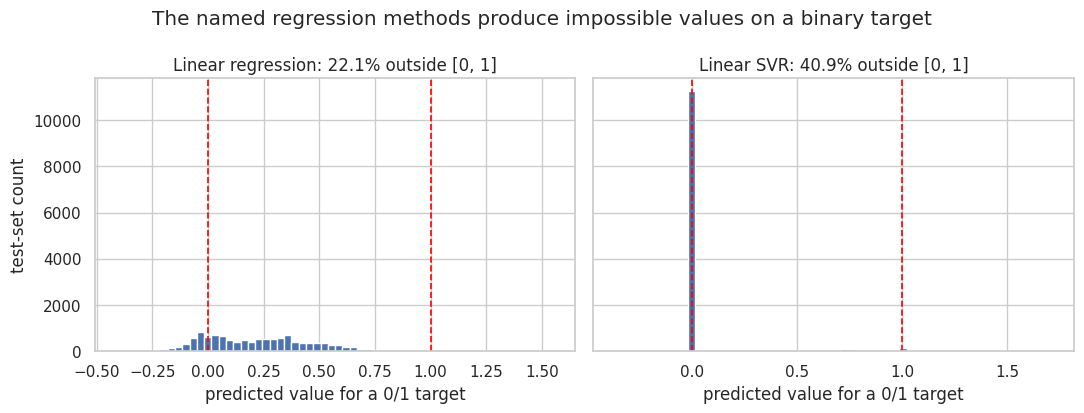

In [8]:
# the picture of the problem: predicted values that cannot be probabilities
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (name, pred) in zip(axes, [("Linear regression", pred_linreg),
                                   ("Linear SVR", pred_svr)]):
    ax.hist(pred, bins=60, color="#4C72B0")
    ax.axvline(0, color="red", ls="--", lw=1.2)
    ax.axvline(1, color="red", ls="--", lw=1.2)
    outside = ((pred < 0) | (pred > 1)).mean() * 100
    ax.set_title(f"{name}: {outside:.1f}% outside [0, 1]")
    ax.set_xlabel("predicted value for a 0/1 target")
axes[0].set_ylabel("test-set count")
fig.suptitle("The named regression methods produce impossible values on a binary target")
fig.tight_layout()
fig.savefig("fig/fig01_regression_break.png", dpi=150, bbox_inches="tight")
plt.show()

Both named methods fit, and both produce predictions below 0 and above 1, values that
cannot be probabilities of anything. The red lines mark the only two values the target can
take. This is not a failed run, it is the documented reason the classification counterparts
exist.

In [9]:
# ----- the classification counterparts -----
# the regression technique built for a binary outcome, fitted plain first
logit = Pipeline([("prep", prep),
                  ("model", LogisticRegression(max_iter=2000, random_state=500))])
logit.fit(X_train, y_train)

# balanced weights are the imbalance correction from the Prepare step
logit_bal = Pipeline([("prep", prep),
                      ("model", LogisticRegression(max_iter=2000, random_state=500,
                                                   class_weight="balanced"))])
logit_bal.fit(X_train, y_train)

lsvc = Pipeline([("prep", prep),
                 ("model", LinearSVC(random_state=500, class_weight="balanced"))])
lsvc.fit(X_train, y_train)

# RBF kernel on a subsample, evaluated on the same full test set
# kernel SVMs scale with the square of n, so the RBF gets a subsample
sub = X_train.sample(8000, random_state=500).index
svc_rbf = Pipeline([("prep", prep),
                    ("model", SVC(kernel="rbf", class_weight="balanced",
                                  random_state=500))])
svc_rbf.fit(X_train.loc[sub], y_train.loc[sub])

print("all four classifiers fitted")

all four classifiers fitted


In [10]:
# every model scored on the same held-out rows
# ROC needs a ranking score, and each model family exposes a different one
def score_of(model, kind):
    # a ranking score per test row: probability, margin, or raw prediction
    if kind == "proba":
        return model.predict_proba(X_test)[:, 1]
    if kind == "margin":
        return model.decision_function(X_test)
    return model.predict(X_test)

models = {
    "Linear regression":  (linreg,    "raw",    pred_linreg >= 0.5),
    "Linear SVR":         (svr,       "raw",    pred_svr >= 0.5),
    "Logistic":           (logit,     "proba",  logit.predict(X_test)),
    "Logistic balanced":  (logit_bal, "proba",  logit_bal.predict(X_test)),
    "LinearSVC balanced": (lsvc,      "margin", lsvc.predict(X_test)),
    "SVC RBF balanced":   (svc_rbf,   "margin", svc_rbf.predict(X_test)),
}

rows = []
for name, (model, kind, label) in models.items():
    label = np.asarray(label).astype(int)
    score = score_of(model, kind)
    rows.append({
        "model": name,
        "accuracy":  accuracy_score(y_test, label),
        "precision": precision_score(y_test, label),
        "recall":    recall_score(y_test, label),
        "f1":        f1_score(y_test, label),
        "roc_auc":   roc_auc_score(y_test, score),
    })

results = pd.DataFrame(rows).set_index("model").round(3)
print(results.to_string())

                    accuracy  precision  recall     f1  roc_auc
model                                                          
Linear regression      0.847      0.768   0.520  0.620    0.902
Linear SVR             0.798      0.832   0.196  0.317    0.707
Logistic               0.851      0.738   0.588  0.654    0.905
Logistic balanced      0.811      0.571   0.843  0.681    0.905
LinearSVC balanced     0.805      0.562   0.849  0.676    0.906
SVC RBF balanced       0.801      0.555   0.850  0.672    0.894


## Step 4 - Report

### The comparison table, read carefully

The table above is the core result. Reading it column by column:

- Every model beats the 76.1% floor a do-nothing predictor would score, but accuracy is
  the least informative column here because of that floor.
- Plain linear regression ranks people surprisingly well (AUC 0.902) even though a fifth
  of its outputs are impossible values. Its failure is calibration, not ordering.
- Linear SVR fails both ways: AUC 0.707 and recall 0.196. Its epsilon-insensitive loss
  ignores residuals smaller than epsilon, which on a 0/1 target is most of them, so the
  fit has little to learn from. Of the two named methods it is the worse match.
- The three classifiers cluster at AUC 0.89 to 0.91. The RBF kernel, fitted on a sixth of
  the training data, matches the linear boundary, so the extra machinery buys nothing.
- The balanced models trade precision for recall on purpose. That trade is the imbalance
  correction working, and the next figures show it directly.

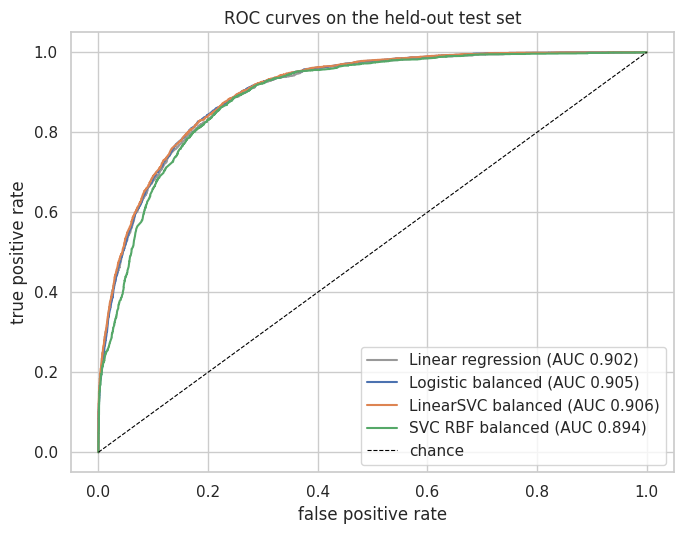

In [11]:
# ROC curves for one model per family
# one curve per model family keeps the chart readable
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, kind, color in [("Linear regression", "raw", "#999999"),
                          ("Logistic balanced", "proba", "#4C72B0"),
                          ("LinearSVC balanced", "margin", "#DD8452"),
                          ("SVC RBF balanced", "margin", "#55A868")]:
    model = models[name][0]
    fpr, tpr, _ = roc_curve(y_test, score_of(model, kind))
    auc = roc_auc_score(y_test, score_of(model, kind))
    ax.plot(fpr, tpr, label=f"{name} (AUC {auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], ls="--", color="black", lw=0.8, label="chance")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves on the held-out test set")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("fig/fig02_roc.png", dpi=150, bbox_inches="tight")
plt.show()

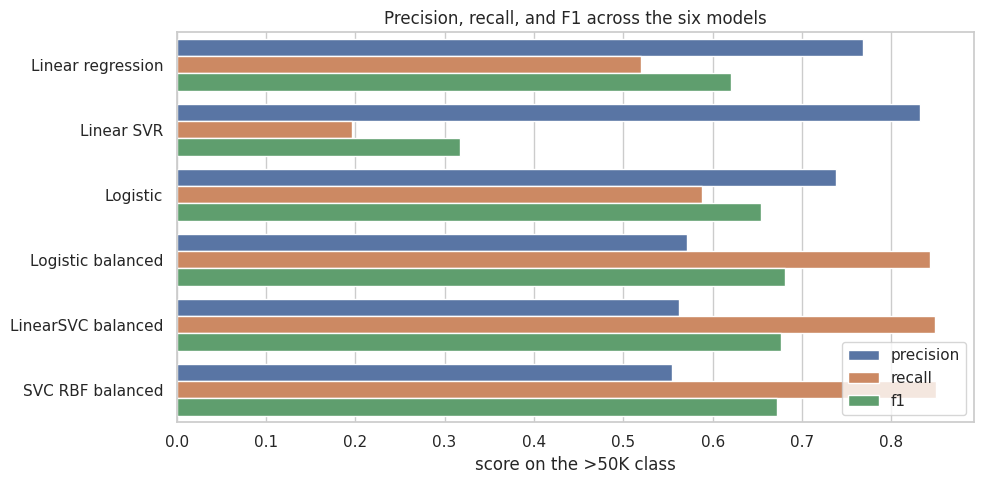

In [12]:
# precision, recall, and F1 side by side for all six models
# long form for a grouped bar chart
plot_df = results[["precision", "recall", "f1"]].reset_index().melt(
    id_vars="model", var_name="metric", value_name="value")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, y="model", x="value", hue="metric", ax=ax)
ax.set_xlabel("score on the >50K class")
ax.set_ylabel("")
ax.set_title("Precision, recall, and F1 across the six models")
ax.legend(title="")
fig.tight_layout()
fig.savefig("fig/fig03_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### Answering the instructor's imbalance question

The graded Micro-Project 2 deck asked whether the 76/24 imbalance would be corrected. The
correction is the class_weight setting, and this figure is the before and after.

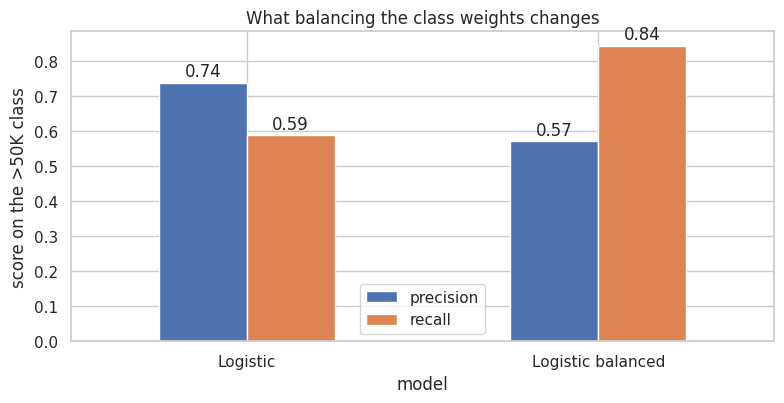

                   precision  recall
model                               
Logistic               0.738   0.588
Logistic balanced      0.571   0.843


In [13]:
# same model, same features, same split. The only change is the class weighting.
# identical model and split, the only change is class_weight
pair = results.loc[["Logistic", "Logistic balanced"], ["precision", "recall"]]

fig, ax = plt.subplots(figsize=(8, 4.2))
pair.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], rot=0)
ax.set_ylabel("score on the >50K class")
ax.set_title("What balancing the class weights changes")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)
fig.tight_layout()
fig.savefig("fig/fig04_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print(pair.round(3).to_string())

Without weighting, the model finds about six in ten of the real high earners. With
weighting it finds more than eight in ten, and pays for it with more false alarms. Which
side of that trade is right depends on use. For screening, where missing a real positive
costs more than a second look at a false one, the balanced version is the right default,
and the threshold stays tunable if the costs change.

### The chosen model up close

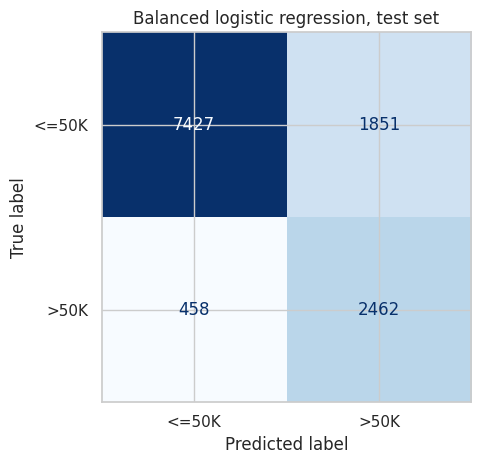

true negatives 7,427   false positives 1,851
false negatives 458   true positives 2,462


In [14]:
# confusion matrix for the balanced logistic model
# raw counts behind the headline metrics
cm = confusion_matrix(y_test, logit_bal.predict(X_test))

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Balanced logistic regression, test set")
fig.tight_layout()
fig.savefig("fig/fig05_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"true negatives {tn:,}   false positives {fp:,}")
print(f"false negatives {fn:,}   true positives {tp:,}")

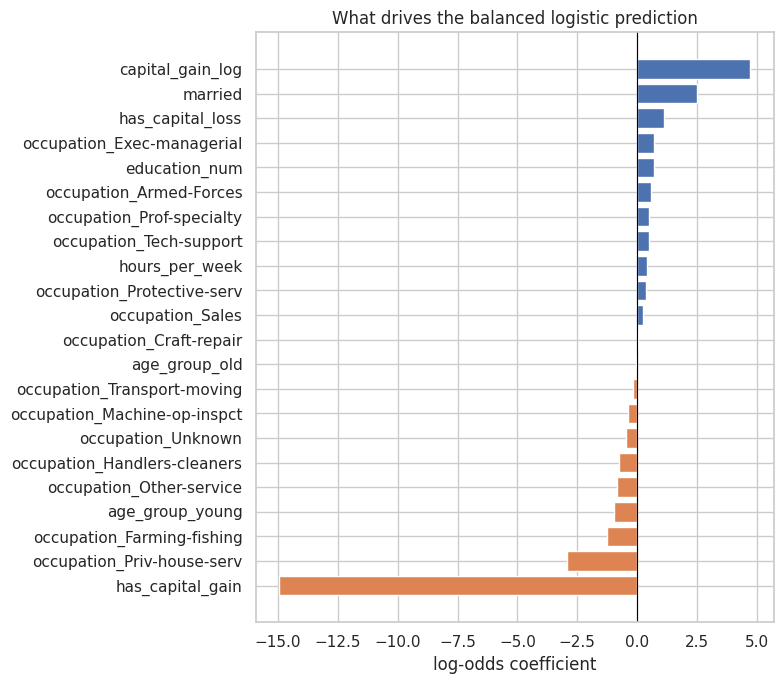

occupation_Armed-Forces       0.58
education_num                 0.71
occupation_Exec-managerial    0.72
has_capital_loss              1.13
married                       2.50
capital_gain_log              4.73


In [15]:
# which inputs drive the prediction, in log-odds units
# pull coefficients with their transformed feature names
feat_names = logit_bal.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(logit_bal.named_steps["model"].coef_[0], index=feat_names)
coefs.index = (coefs.index.str.replace("num__", "").str.replace("bin__", "")
               .str.replace("cat__", ""))
coefs = coefs.sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#DD8452" if v < 0 else "#4C72B0" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("log-odds coefficient")
ax.set_title("What drives the balanced logistic prediction")
fig.tight_layout()
fig.savefig("fig/fig06_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print(coefs.round(2).tail(6).to_string())

Reading the top of the chart, with the caveat that the numeric coefficients are per
standard deviation while the indicator coefficients are against a reference group:

- capital_gain_log carries the single largest coefficient (4.73). It is a narrow but
  nearly decisive marker: only 8.3% of the sample has any gain, but where one exists it
  almost settles the prediction, which is what the Micro-Project 2 density plot showed.
- married (2.50) is the largest of the broad demographic effects, well above one standard
  deviation of education (0.71). The Micro-Project 2 surprise survives controlling for
  everything else in the model. The hypothesis called marital status secondary, and that
  part of the hypothesis is wrong.
- education_num and hours_per_week are confirmed as strong positive effects among the
  variables that apply to everyone, exec-managerial and prof-specialty occupations add to
  them, and the mid and old age groups sit above the young reference group.

### Performance across the groups documented in Micro-Project 2

In [16]:
# recall and false positive rate of the chosen model, sliced by sex and race.
# these columns were excluded from the model inputs, this is evaluation only.
test_view = df.loc[X_test.index, ["sex", "race"]].copy()
test_view["actual"] = y_test.values
test_view["pred"] = logit_bal.predict(X_test)

# recall and false positive rate per group level
def group_rates(col):
    out = []
    for level, g in test_view.groupby(col, observed=True):
        pos, neg = g[g["actual"] == 1], g[g["actual"] == 0]
        out.append({col: level, "n": len(g),
                    "recall": pos["pred"].mean() if len(pos) else np.nan,
                    "false_pos_rate": neg["pred"].mean() if len(neg) else np.nan})
    return pd.DataFrame(out).set_index(col)

by_sex = group_rates("sex")
by_race = group_rates("race")
print(by_sex.round(3).to_string())
print()
print(by_race.round(3).to_string())

           n  recall  false_pos_rate
sex                                 
Female  4063   0.726           0.061
Male    8135   0.864           0.288

                        n  recall  false_pos_rate
race                                             
Amer-Indian-Eskimo    113   0.846           0.160
Asian-Pac-Islander    366   0.853           0.207
Black                1198   0.844           0.091
Other                 110   0.900           0.120
White               10411   0.843           0.215


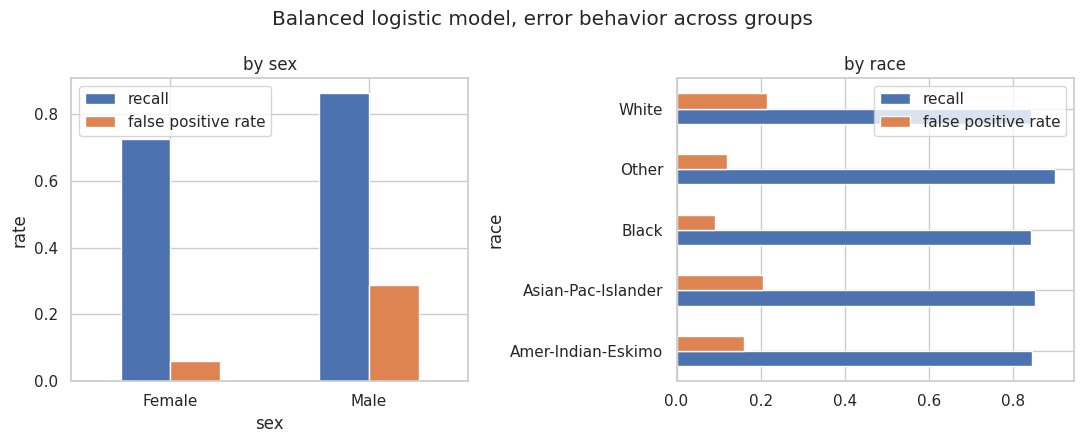

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
by_sex[["recall", "false_pos_rate"]].plot(kind="bar", ax=axes[0], rot=0,
                                          color=["#4C72B0", "#DD8452"])
axes[0].set_title("by sex")
axes[0].set_ylabel("rate")
by_race[["recall", "false_pos_rate"]].plot(kind="barh", ax=axes[1],
                                           color=["#4C72B0", "#DD8452"])
axes[1].set_title("by race")
for ax in axes:
    ax.legend(["recall", "false positive rate"])
fig.suptitle("Balanced logistic model, error behavior across groups")
fig.tight_layout()
fig.savefig("fig/fig07_fairness.png", dpi=150, bbox_inches="tight")
plt.show()

The model was never shown sex or race, and its errors still differ across those groups,
because the inputs it does see (occupation, hours, marriage, education) carry the 1994
disparities with them. The sex gap is the large one: recall is 0.86 for men against 0.73
for women, and the false positive rate for men (0.29) is nearly five times the rate for
women (0.06). Across race groups recall is tight (0.84 to 0.90) while false positive
rates spread from 0.09 to 0.22, with the two groups near 110 test rows too small to
estimate precisely. The point of this section is not a verdict, it is that anyone acting
on this model gets the differences documented instead of discovered later.

## Step 5 - Act

**Chosen model: the balanced logistic regression.** Every model ranks equally well (AUC
near 0.90), so the tiebreakers are practical: it outputs real probabilities, its
coefficients can be read and defended, it retrains in seconds, and its class weighting
answers the imbalance question directly. The RBF kernel matched it while costing far more
compute, which is a reason to keep the simpler model.

**Answer to the problem statement.** The attributes most associated with crossing the
50,000 dollar threshold in the 1994 sample, holding the others in the model constant: being
married with a spouse present, education, capital-gain participation, hours worked, and
holding an executive or professional occupation, with earnings peaking in the mid career
group.

**Verdict on the hypothesis: partially supported, and refined.** Education and hours are
confirmed as strong correlates, exactly as stated. The hypothesis erred in calling marital
status secondary: its coefficient is the largest of the demographic effects, above a full
standard deviation of education. The refined statement reads: being married with a spouse
present, education, and hours worked are the dominant broad correlates, capital-gain
participation is a narrow but nearly decisive marker for the few who have it, and
occupation contributes additional signal.

**The imbalance answer, closed.** Corrected at the modeling stage with class weights,
never by resampling the evaluation data. The correction raises recall on the >50K class
from 0.59 to 0.84 while precision falls from 0.74 to 0.57, and the threshold remains
tunable if the costs of the two error types change.

**What acting on this looks like.** As a screening tool on comparable data, the balanced
model flags likely high earners for review at high recall. Anyone deploying it should
publish the group-level error rates from the fairness section alongside it and monitor
them, the five-fold false-positive gap between men and women first among them, because
the disparities ride in through the legitimate-looking inputs.

**Limitations.** The data describes 1994, not the present labor market. The design is
observational, so every coefficient is an association, not a cause: the married effect in
particular bundles whatever selects people into stable marriages with any effect of
marriage itself. And the 50,000 dollar line is a single threshold, not a full earnings
model.

**Handoff to Micro-Project 4.** The final micro-project requires deep learning regression
on time-series data. This dataset is a single 1994 cross-section with no time dimension,
so Micro-Project 4 will introduce a time-series dataset, and the model-comparison habits
built here carry over as the baseline discipline.